In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import math
import numpy as np

In [2]:
# Descargar set de datos Fashion MNIST
datos, metadatos = tfds.load('fashion_mnist', as_supervised=True, with_info=True)

In [3]:
metadatos

tfds.core.DatasetInfo(
    name='fashion_mnist',
    full_name='fashion_mnist/3.0.1',
    description="""
    Fashion-MNIST is a dataset of Zalando's article images consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes.
    """,
    homepage='https://github.com/zalandoresearch/fashion-mnist',
    data_dir='C:\\Users\\alexi\\tensorflow_datasets\\fashion_mnist\\3.0.1',
    file_format=tfrecord,
    download_size=29.45 MiB,
    dataset_size=36.42 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@article{DBLP

In [4]:
datos_entrenamiento, datos_pruebas = datos['train'], datos['test']

In [5]:
nombres_clases = metadatos.features['label'].names
nombres_clases

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [6]:
def normalizar(imagenes, etiquetas):
    imagenes = tf.cast(imagenes, tf.float32)
    imagenes /= 255
    return imagenes, etiquetas

In [7]:
datos_entrenamiento = datos_entrenamiento.map(normalizar)
datos_pruebas = datos_pruebas.map(normalizar)

In [8]:
datos_entrenamiento = datos_entrenamiento.cache()
datos_pruebas = datos_pruebas.cache()

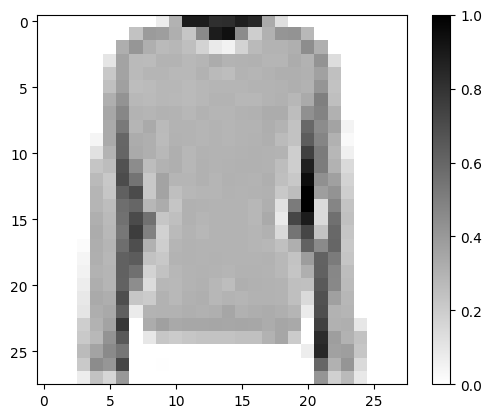

In [9]:
for imagen, etiqueta in datos_entrenamiento.take(1):
    break

imagen = imagen.numpy().reshape((28,28))

plt.figure()
plt.imshow(imagen, cmap=plt.cm.binary)
plt.colorbar()
plt.grid(False)
plt.show()

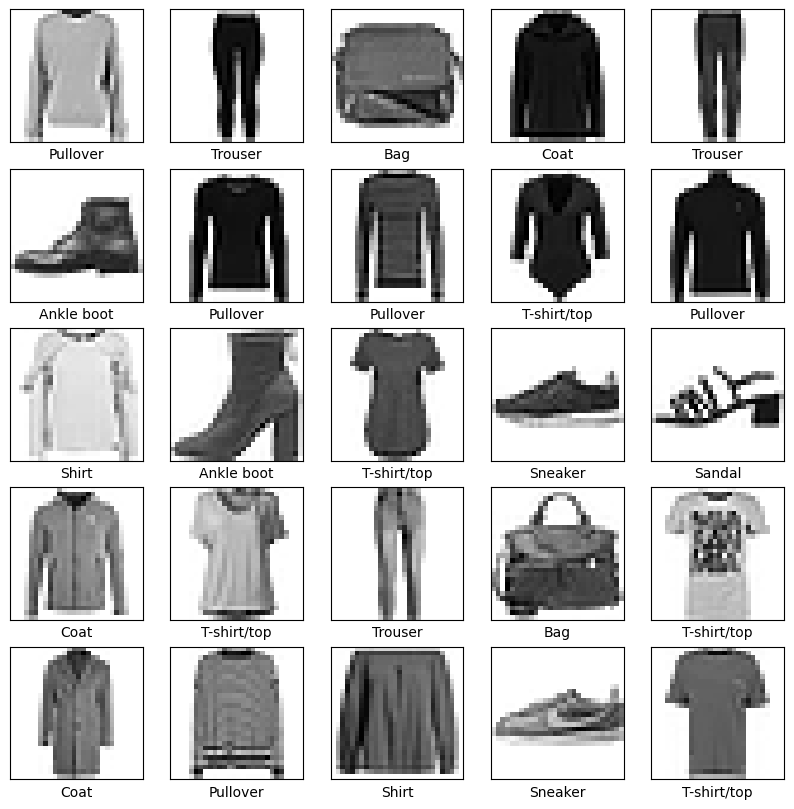

In [10]:
plt.figure(figsize=(10,10))

for i, (imagen, etiqueta) in enumerate(datos_entrenamiento.take(25)):
    imagen = imagen.numpy().reshape((28,28))

    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    plt.imshow(imagen, cmap=plt.cm.binary)
    plt.xlabel(nombres_clases[etiqueta])

plt.show()

In [11]:
modelo = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28,1)),
    tf.keras.layers.Dense(50, activation=tf.nn.relu),
    tf.keras.layers.Dense(50, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

c:\Users\alexi\anaconda3\envs\ia_actividades\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
modelo.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [13]:
TAMANO_LOTE = 32

In [14]:
num_ej_entrenamiento = metadatos.splits["train"].num_examples
num_ej_pruebas = metadatos.splits["test"].num_examples

print(num_ej_entrenamiento)
print(num_ej_pruebas)

60000
10000


In [15]:
datos_entrenamiento = datos_entrenamiento.repeat().shuffle(num_ej_entrenamiento).batch(TAMANO_LOTE)
datos_pruebas = datos_pruebas.batch(TAMANO_LOTE)

In [16]:
historial = modelo.fit(
    datos_entrenamiento,
    epochs=5,
    steps_per_epoch=math.ceil(num_ej_entrenamiento / TAMANO_LOTE)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8164 - loss: 0.5222
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8620 - loss: 0.3803
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8725 - loss: 0.3489
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8800 - loss: 0.3275
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8869 - loss: 0.3092


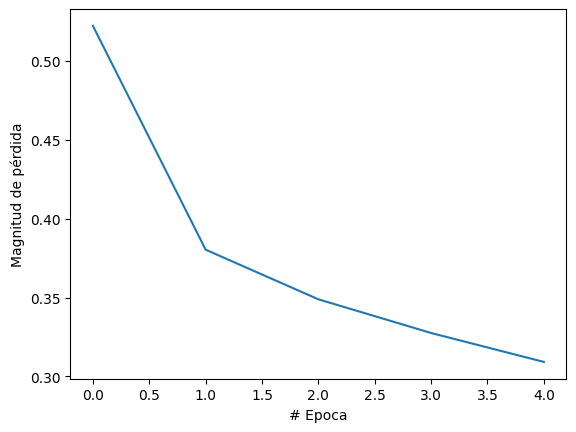

In [17]:
plt.xlabel("# Epoca")
plt.ylabel("Magnitud de pérdida")
plt.plot(historial.history["loss"])
plt.show()

In [18]:
for imagenes_prueba, etiquetas_prueba in datos_pruebas.take(1):
    imagenes_prueba = imagenes_prueba.numpy()
    etiquetas_prueba = etiquetas_prueba.numpy()

predicciones = modelo.predict(imagenes_prueba)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


In [19]:
def graficar_imagen(i, arr_predicciones, etiquetas_reales, imagenes):
    arr_predicciones, etiqueta_real, img = arr_predicciones[i], etiquetas_reales[i], imagenes[i]

    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img[...,0], cmap=plt.cm.binary)

    etiqueta_prediccion = np.argmax(arr_predicciones)

    if etiqueta_prediccion == etiqueta_real:
        color = "blue"
    else:
        color = "red"

    plt.xlabel("{} {:2.0f}% ({})".format(
        nombres_clases[etiqueta_prediccion],
        100*np.max(arr_predicciones),
        nombres_clases[etiqueta_real]),
        color=color
    )

In [20]:
def graficar_valor_arreglo(i, arr_predicciones, etiqueta_real):
    arr_predicciones, etiqueta_real = arr_predicciones[i], etiqueta_real[i]

    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])

    grafica = plt.bar(range(10), arr_predicciones, color="#777777")
    plt.ylim([0,1])

    etiqueta_prediccion = np.argmax(arr_predicciones)

    grafica[etiqueta_prediccion].set_color('red')
    grafica[etiqueta_real].set_color('blue')

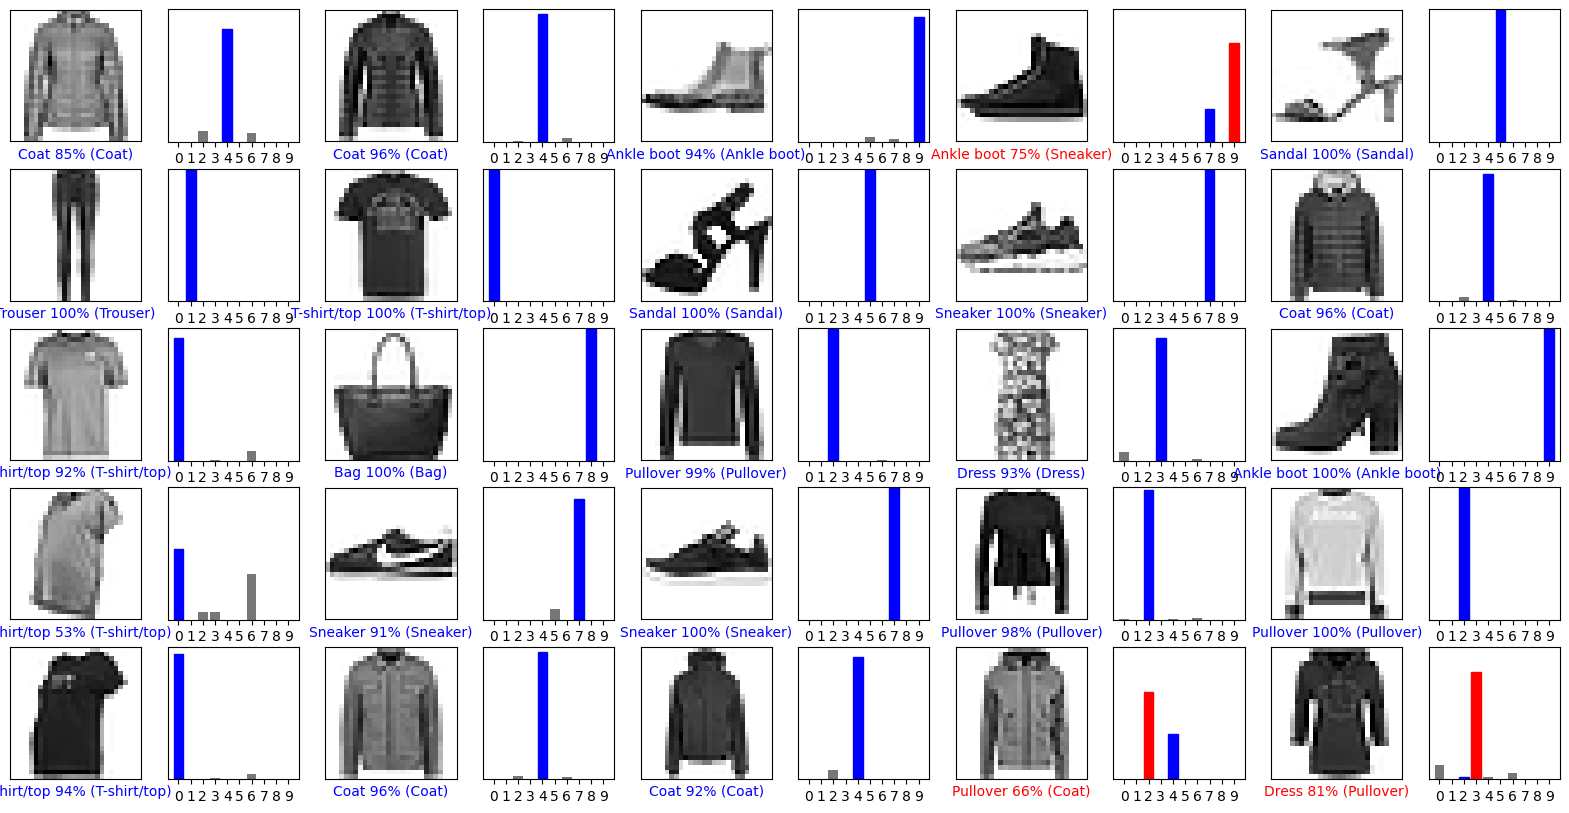

In [21]:
filas = 5
columnas = 5
num_imagenes = filas * columnas

plt.figure(figsize=(2*2*columnas, 2*filas))

for i in range(num_imagenes):

    plt.subplot(filas, 2*columnas, 2*i+1)
    graficar_imagen(i, predicciones, etiquetas_prueba, imagenes_prueba)

    plt.subplot(filas, 2*columnas, 2*i+2)
    graficar_valor_arreglo(i, predicciones, etiquetas_prueba)

plt.show()

In [22]:
imagen = imagenes_prueba[24]
imagen = np.array([imagen])

prediccion = modelo.predict(imagen)

print("Prediccion:", nombres_clases[np.argmax(prediccion[0])])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Prediccion: Dress


In [23]:
modelo.save("modelo_ropa.h5")

In [24]:
from IPython.display import display
import ipywidgets as widgets
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import io

uploader = widgets.FileUpload(
    accept='image/*',
    multiple=False,
    description='Subir imagen'
)

output = widgets.Output()

def clasificar_imagen(change):
    with output:
        output.clear_output()

        if not uploader.value:
            print("Por favor sube una imagen.")
            return

        archivo = uploader.value[0]
        contenido = archivo['content']

        # Abrir imagen
        img = Image.open(io.BytesIO(contenido)).convert('L')
        img = img.resize((28,28))

        img_array = np.array(img).astype("float32") / 255.0

        # Invertir colores (ayuda para Fashion MNIST)
        img_array = 1.0 - img_array

        img_modelo = img_array.reshape(1,28,28,1)

        prediccion = modelo.predict(img_modelo, verbose=0)

        clase_predicha = np.argmax(prediccion[0])
        confianza = np.max(prediccion[0]) * 100

        plt.imshow(img_array, cmap='gray')
        plt.title("Imagen procesada")
        plt.axis("off")
        plt.show()

        print("Predicción:", nombres_clases[clase_predicha])
        print(f"Confianza: {confianza:.2f}%")

        print("\nProbabilidades:")
        for i, nombre in enumerate(nombres_clases):
            print(f"{nombre}: {prediccion[0][i]*100:.2f}%")

uploader.observe(clasificar_imagen, names='value')

display(uploader, output)

FileUpload(value=(), accept='image/*', description='Subir imagen')

Output()

### ¿Qué es el formato H5?

El formato **H5 (HDF5)** es un tipo de archivo utilizado para almacenar grandes cantidades de datos de manera organizada. En aprendizaje automático se usa comúnmente para **guardar modelos entrenados**.

### ¿Para qué sirve?

El formato **.h5** permite guardar toda la información de un modelo de red neuronal en un solo archivo, incluyendo:

- La arquitectura del modelo
- Los pesos aprendidos durante el entrenamiento
- Los parámetros del modelo

